# 학습된 모델 저장

- 학습이 완료된 모델을 파일로 저장하여, 이후 추가 학습이나 예측 서비스에 사용할 수 있도록 한다.
- 파이토치(PyTorch)는 **모델의 파라미터만 저장**하는 방법과 **모델의 구조와 파라미터를 모두 저장**하는 두 가지 방식을 제공한다.
- 저장 함수
  - `torch.save(저장할 객체, 저장 경로)`
- 보통 저장 파일의 확장자는 `.pt`나 `.pth`를 사용한다.

## 모델 전체 저장 및 불러오기

- 저장하기
  - `torch.save(model, 저장 경로)`
- 불러오기
  - `load_model = torch.load(저장 경로)`
- 모델 저장 시 **피클(pickle)**을 사용해 직렬화되므로, 모델을 불러오는 실행 환경에도 저장할 때 사용한 클래스 정의가 필요하다.
- 저장하는 것은 그저 모델 객체와 그 내부 하이퍼 파라미터 및 파라미터 뿐이므로 모델 객체가 상속하는 클래스 정의가 필요한 것이다.

## 모델의 파라미터만 저장

-   모델을 구성하는 파라미터만 저장한다.
-   모델의 구조는 저장하지 않기 때문에 불러올 때 **모델을 먼저 생성하고 생성한 모델에 불러온 파라미터를 덮어씌운다.**
    -   model.parameters 속성 이용 
-   모델의 파라미터는 **state_dict** 형식으로 저장한다.

### state_dict

-   모델의 파라미터 Tensor들을 레이어 단위별로 나누어 저장한 Ordered Dictionary (OrderedDict) | 순서(Layer)를 가진 딕셔너리
-   `모델객체.state_dict()` 메소드를 이용해 조회 -> ordered dictionary 형태로 반환
-   모델의 state_dict을 조회 후 저장한다.
    -   `torch.save(model.state_dict(), "저장경로")`
-   생성된 모델에 읽어온 state_dict를 덮어씌운다.
    -   `new_model.load_state_dict(torch.load("state_dict저장경로"))`


In [ ]:
import torch
import torch.nn as nn
model = nn.Sequential(
    nn.Linear(10, 1),
    nn.Linear(1, 5),
    nn.Linear(5, 3)
)
model.parameters        # 하이퍼 파라미터
model.state_dict()      # weight, bias등 파라미터 

OrderedDict([('0.weight',
              tensor([[ 0.2034, -0.0026, -0.1211,  0.2797, -0.2496,  0.0793, -0.1077,  0.0942,
                        0.1480, -0.1879]])),
             ('0.bias', tensor([-0.2143])),
             ('1.weight',
              tensor([[ 0.7557],
                      [-0.6417],
                      [-0.9509],
                      [ 0.2779],
                      [-0.3223]])),
             ('1.bias', tensor([-0.7930, -0.7031, -0.0381, -0.2110,  0.6595])),
             ('2.weight',
              tensor([[ 0.3262,  0.1709,  0.0835,  0.2305, -0.0410],
                      [ 0.3841, -0.3367,  0.2761,  0.3493, -0.3359],
                      [ 0.3411, -0.3442, -0.3937,  0.1579, -0.0609]])),
             ('2.bias', tensor([ 0.2708, -0.0583,  0.3782]))])

## Checkpoint 저장 및 불러오기

- 모델과 관련있는 모든 내용을 통째로 저장! | 모델, loss_fn, optimizer, epoch이나 step 등까지 모든 상황 
- 학습이 끝나지 않은 모델을 저장하고, 나중에 이어서 학습시키려면 모델의 구조와 파라미터뿐만 아니라 optimizer, loss 함수 등 학습에 필요한 객체들도 함께 저장해야 한다. | 학습이 끝난 경우 모델만 저장할 수도 있어
- 딕셔너리(Dictionary)에 저장하려는 값들을 key-value 쌍으로 구성하여 `torch.save()`를 이용해 저장 -> 디렉토리째로 저장돼
- optimizer의 경우 모멘텀이나 학습률 최적화 등의 파라미터가 존재하기에 state_dict 값을 저장할 필요가 있는 것이다.

```python
# 저장
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': train_loss
}, "저장경로")

# 불러오기
model = MyModel()
optimizer = optim.Adam(model.parameters())

# 불러온 checkpoint를 이용해 이전 학습 상태 복원
checkpoint = torch.load("저장경로")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']
```

In [5]:
# 간단한 모델 정의
import torch
import torch.nn as nn

# 딥러닝 모델 클래스 정의
class MyModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(3, 4) # 3 X 4 + 4 | weight, bias 수 
        self.lr2 = nn.Linear(4, 2)
        self.relu = nn.ReLU() # activation함수->파라미터가 없는 단순 계산함수. relu(X) = max(X, 0)
    def forward(self, X):
        X = self.lr1(X)
        X = self.relu(X)
        X = self.lr2(X)
        return X

In [6]:
# 모델 생성
model = MyModel()
model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [7]:
# 모델에서 레이어 객체를 조회
model.lr1
model.lr1.in_features, model.lr1.weight

(3,
 Parameter containing:
 tensor([[-0.1856,  0.5606,  0.4892],
         [ 0.2768, -0.2601, -0.1846],
         [-0.2486, -0.1268,  0.1834],
         [-0.3200,  0.0238,  0.3746]], requires_grad=True))

In [8]:
import os
os.makedirs("saved_models", exist_ok=True)

In [9]:
################################################
#  모델을 저장
################################################
torch.save(model, "saved_models/my_model.pt")

In [ ]:
import torch
################################################
#  저장된 모델 Load
################################################
load_model = torch.load("saved_models/my_model.pt", weights_only=False)
# 피클의 역직렬화는 보안 문제가 심각하므로 피클을 사용하지 않는 weights_only=True가 기본값으로 채택되었다.

In [11]:
load_model

MyModel(
  (lr1): Linear(in_features=3, out_features=4, bias=True)
  (lr2): Linear(in_features=4, out_features=2, bias=True)
  (relu): ReLU()
)

In [12]:
################################################
#  모델에 Layer들을 조회. 모델.instance변수명
################################################
lr_layer = model.lr1
lr_layer

Linear(in_features=3, out_features=4, bias=True)

In [13]:
################################################
#  Layer의 파라미터(weight/bias) 조회
################################################
lr1_weight = lr_layer.weight
lr1_bias = lr_layer.bias

In [14]:
lr1_weight

Parameter containing:
tensor([[-0.1856,  0.5606,  0.4892],
        [ 0.2768, -0.2601, -0.1846],
        [-0.2486, -0.1268,  0.1834],
        [-0.3200,  0.0238,  0.3746]], requires_grad=True)

In [15]:
lr1_bias

Parameter containing:
tensor([ 0.5074,  0.0862,  0.1895, -0.0916], requires_grad=True)

In [16]:
######################################################
# 모델의 파라미터들(weight들, bias들)만 저장/불러오기
######################################################
state_dict = model.state_dict()
state_dict

OrderedDict([('lr1.weight',
              tensor([[-0.1856,  0.5606,  0.4892],
                      [ 0.2768, -0.2601, -0.1846],
                      [-0.2486, -0.1268,  0.1834],
                      [-0.3200,  0.0238,  0.3746]])),
             ('lr1.bias', tensor([ 0.5074,  0.0862,  0.1895, -0.0916])),
             ('lr2.weight',
              tensor([[-0.2808, -0.3590, -0.0329,  0.2536],
                      [ 0.0240,  0.1658, -0.2940,  0.4527]])),
             ('lr2.bias', tensor([-0.1247,  0.0232]))])

In [17]:
state_dict.keys()

odict_keys(['lr1.weight', 'lr1.bias', 'lr2.weight', 'lr2.bias'])

In [18]:
###################
# state_dict 저장
################### 

torch.save(state_dict, "saved_models/my_model_parameter.pt")

In [19]:
#####################
# state_dict load
#####################
sd = torch.load("saved_models/my_model_parameter.pt")

In [20]:
# load한 state_dict를 모델 파라미터에 적용(덮어 씌운다.)
new_model = MyModel()
new_model.state_dict()

OrderedDict([('lr1.weight',
              tensor([[ 0.3331, -0.4810,  0.0832],
                      [-0.3517, -0.5530, -0.2109],
                      [ 0.4713, -0.1522, -0.0439],
                      [ 0.3561,  0.3139, -0.1542]])),
             ('lr1.bias', tensor([ 0.1151,  0.4597,  0.2114, -0.4057])),
             ('lr2.weight',
              tensor([[-0.3166, -0.3400,  0.0695, -0.2039],
                      [-0.1238, -0.2331,  0.2014,  0.3405]])),
             ('lr2.bias', tensor([-0.3897, -0.4586]))])

In [21]:
new_model.load_state_dict(sd)

<All keys matched successfully>

In [22]:
new_model.state_dict()

OrderedDict([('lr1.weight',
              tensor([[-0.1856,  0.5606,  0.4892],
                      [ 0.2768, -0.2601, -0.1846],
                      [-0.2486, -0.1268,  0.1834],
                      [-0.3200,  0.0238,  0.3746]])),
             ('lr1.bias', tensor([ 0.5074,  0.0862,  0.1895, -0.0916])),
             ('lr2.weight',
              tensor([[-0.2808, -0.3590, -0.0329,  0.2536],
                      [ 0.0240,  0.1658, -0.2940,  0.4527]])),
             ('lr2.bias', tensor([-0.1247,  0.0232]))])

In [ ]:
# torchinof 패키지 설치: 파이토치 모델 구조를 조사해주는 패키지.
# !pip install torchinfo

In [ ]:
from torchinfo import summary
# 모델의 전체적인 개형 및 파라미터 설명 
## Non-trainable params : white-box 파트를 유지하기 위해? 고정된 레이어를 사용하는 경우가 있음 | requires_grad=False 인 애들 
summary(model)

Layer (type:depth-idx)                   Param #
MyModel                                  --
├─Linear: 1-1                            16
├─Linear: 1-2                            10
├─ReLU: 1-3                              --
Total params: 26
Trainable params: 26
Non-trainable params: 0

In [25]:
# input data 의 shape을 지정하면 각 Layer의 output shape을 출력한다.
summary(model, (100, 3))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [100, 2]                  --
├─Linear: 1-1                            [100, 4]                  16
├─ReLU: 1-2                              [100, 4]                  --
├─Linear: 1-3                            [100, 2]                  10
Total params: 26
Trainable params: 26
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

# 문제 유형별 MLP 네트워크
- 해결하려는 문제 유형에 따라 출력 Layer의 구조가 바뀐다.
- 딥러닝 구조에서 **Feature를 추출하는 Layer 들을 Backbone** 이라고 하고 **추론하는 Layer들을 Head** 라고 한다. 

- ex) 작성되어 있는 알려진 Layers 를 가져와서 쓰니까 Backbone이라고 부르지 ㅋㅋ


> - MLP(Multi Layer Perceptron), DNN(Deep Neural Network), ANN(Artificial Neural Network)
>     -   Fully Connected Layer(nn.Linear)로 구성된 딥러닝 모델
>     -   input feature들 모두에 대응하는 weight들(가중치)을 사용한다.
> 

## Boston Housing Dataset - **Regression(회귀) 문제**

보스턴 주택가격 dataset은 다음과 같은 속성을 바탕으로 해당 타운 주택 가격의 중앙값을 예측하는 문제.

-   CRIM: 범죄율
-   ZN: 25,000 평방피트당 주거지역 비율
-   INDUS: 비소매 상업지구 비율
-   CHAS: 찰스강에 인접해 있는지 여부(인접:1, 아니면:0)
-   NOX: 일산화질소 농도(단위: 0.1ppm)
-   RM: 주택당 방의 수
-   AGE: 1940년 이전에 건설된 주택의 비율
-   DIS: 5개의 보스턴 직업고용센터와의 거리(가중 평균)
-   RAD: 고속도로 접근성
-   TAX: 재산세율
-   PTRATIO: 학생/교사 비율
-   B: 흑인 비율
-   LSTAT: 하위 계층 비율
    <br><br>
-   **Target**
    -   MEDV: 타운의 주택가격 중앙값(단위: 1,000달러)


In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 데이터 불러오기 
data = pd.read_csv('data/boston_hosing.csv')
X = data.drop(columns='MEDV').values
y = data['MEDV'].values.reshape(-1, 1)

# Feature Scaling - Standard Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=0) # stratify=y -> 분류 문제 
X_train.shape, X_test.shape, y_train.shape, y_test.shape
# data.isna().sum()
# y_test.min(), y_test.max(), y_test.std(), y_test.mean()

((404, 13), (102, 13), (404, 1), (102, 1))

In [113]:
# Dataset 생성
from torch.utils.data import TensorDataset, DataLoader
trainset = TensorDataset(
    # 모델 파라미터와 동일한 데이터 타입 설정 
    torch.FloatTensor(X_train),
    torch.FloatTensor(y_train)
)
testset = TensorDataset(
    torch.FloatTensor(X_test),
    torch.FloatTensor(y_test)
)

# DataLoader 생성
train_loader = DataLoader(
    trainset,
    batch_size=100,
    shuffle=True,
    drop_last=True
)
test_loader = DataLoader(
    testset,
    batch_size=102, # 전체 테스트 셋 
)
len(trainset), len(testset), len(train_loader), len(test_loader)

(404, 102, 4, 1)

In [114]:
# 모델 클래스 정의 
## 모델의 복잡도가 한계가 있기에 feature를 무작정 많이 고려한다고 모델의 성능이 막 좋아지지는 않는다. 
import torch
import torch.nn as nn

class BostonModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lr1 = nn.Linear(13, 1000)   # 시작 Feature 수 고정 | 다양한 초기 관계 학습
        self.lr2 = nn.Linear(1000, 200)   # Feature 압축
        self.lr3 = nn.Linear(200, 20)
        self.lr4 = nn.Linear(20, 1)     # Regresion Output 수 : 1개 

    def forward(self, X):
        '''
        Args:
            X(Tensor) - (batch_size, feature 수) 꼴 
        Returns:
            - 최종 예측 값 
        '''
        X = self.lr1(X)
        X = nn.ReLU()(X)    # 모델 객체 먼저 생성 -> 이후 값 대입 
        X = self.lr2(X)
        X = nn.ReLU()(X)
        X = self.lr3(X)
        X = nn.ReLU()(X)

        return self.lr4(X)

In [115]:
# 모델 객체, loss_fn, optimizer 객체 생성
import torch.optim as optim
from torchinfo import summary

model = BostonModel()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(params = model.parameters(), lr=0.001)

# model, X, y 는 같은 device에 존재해야해 
model.to(device)

summary(model)

Layer (type:depth-idx)                   Param #
BostonModel                              --
├─Linear: 1-1                            14,000
├─Linear: 1-2                            200,200
├─Linear: 1-3                            4,020
├─Linear: 1-4                            21
Total params: 218,241
Trainable params: 218,241
Non-trainable params: 0

In [ ]:
# 학습 및 평가 
## epoch 별로 평가를 진행하는 이유는 진행 상황을 보며 최적의 모델을 선택하기 위함이다. 
epochs = 500
loss_train_list = []
loss_test_list = []
for epoch in range(epochs):
    # 학습 모드
    model.train()
    loss_train = 0
    for X_train, y_train in train_loader:
        # Device 옮기기
        X_train, y_train = X_train.to(device), y_train.to(device)
        # 예측
        pred = model(X_train) # 딥러닝 학습은 오직 input 
        # Loss 계산
        loss = loss_fn(pred, y_train) ### 여기가 400,1 vs 400 이라서 문제 발생? 
        loss_train += loss.item()
        # Gradient 계산
        loss.backward()
        # Optimizer 최적화
        optimizer.step()
        # Gradient 초기화
        optimizer.zero_grad()
    loss_train /= len(train_loader)
    loss_train_list.append(loss_train)
    
    # 평가 모드
    model.eval()
    loss_test = 0
    with torch.no_grad():
        for X_test, y_test in test_loader:
            # Device 옮기기 
            X_test, y_test = X_test.to(device), y_test.to(device)
            # 예측
            pred = model(X_test)
            # Loss 계산 - Regression 이라
            loss = loss_fn(pred, y_test)
            loss_test += loss.item()
        loss_test /= len(test_loader)
        loss_test_list.append(loss_train)
    
    print(f'[{epoch}/{epochs}]\ntrain_loss : {loss_train:.5f}\ntest_loss : {loss_test:.5f}')

[0/500]
train_loss : 596.73114
test_loss : 550.99109
[1/500]
train_loss : 551.37967
test_loss : 494.71561
[2/500]
train_loss : 485.51002
test_loss : 411.27737
[3/500]
train_loss : 383.29257
test_loss : 304.85632
[4/500]
train_loss : 262.70464
test_loss : 195.21431
[5/500]
train_loss : 157.66426
test_loss : 119.38649
[6/500]
train_loss : 90.70690
test_loss : 104.07249
[7/500]
train_loss : 83.73718
test_loss : 109.34754
[8/500]
train_loss : 75.34326
test_loss : 85.74807
[9/500]
train_loss : 49.09354
test_loss : 68.57449
[10/500]
train_loss : 37.61182
test_loss : 65.64809
[11/500]
train_loss : 34.87893
test_loss : 62.29997
[12/500]
train_loss : 31.60282
test_loss : 54.47027
[13/500]
train_loss : 23.40968
test_loss : 48.24531
[14/500]
train_loss : 21.96464
test_loss : 44.59338
[15/500]
train_loss : 21.17156
test_loss : 41.75620
[16/500]
train_loss : 19.92094
test_loss : 38.88667
[17/500]
train_loss : 18.36255
test_loss : 37.46549
[18/500]
train_loss : 17.59941
test_loss : 36.55757
[19/500]

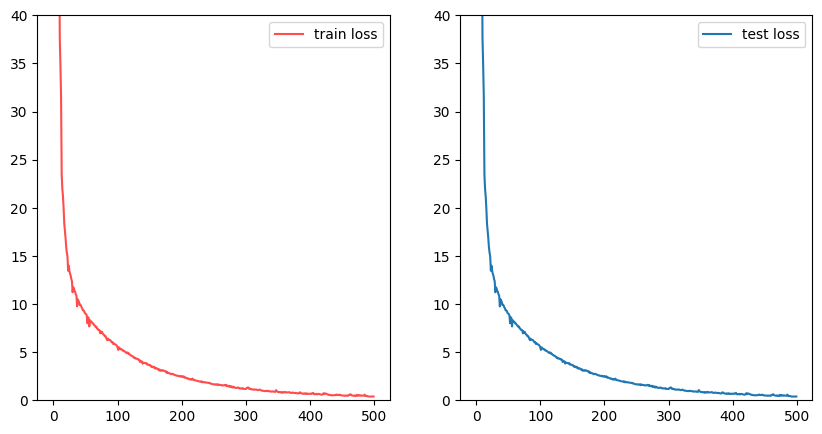

In [119]:
# 결과 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(range(500), loss_train_list, label='train loss', color='r', alpha=0.7)
plt.ylim(0, 40)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(500), loss_test_list, label='test loss', alpha=1)
plt.ylim(0, 40)
plt.legend()
plt.show()

In [125]:
# 모델 저장
import os
os.makedirs('saved_models', exist_ok=True)
model_dir = 'saved_models'
model_name = 'boston_model.pt'
model_param_name = 'boston_model_state_dict.pt'
torch.save(model, os.path.join(model_dir, model_name))
torch.save(model.state_dict(), os.path.join(model_dir, model_param_name))

In [126]:
# 모델 불러오기 + 최종 평가 
## loading 할 때 weight만을 가져올 지 정해 
load_boston_model = torch.load(os.path.join(model_dir, model_name), weights_only=False)

In [127]:
# 추론
new_X, _ = trainset[:5]
load_boston_model.eval()
with torch.no_grad():
    new_y = load_boston_model(new_X)

## 분류 (Classification)

### Fashion MNIST Dataset - **다중분류(Multi-Class Classification) 문제**

10개의 범주(category)와 70,000개의 흑백 이미지로 구성된 [패션 MNIST](https://github.com/zalandoresearch/fashion-mnist) 데이터셋.
이미지는 해상도(28x28 픽셀)가 낮고 다음처럼 개별 의류 품목을 나타낸다:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>그림</b> <a href="https://github.com/zalandoresearch/fashion-mnist">패션-MNIST 샘플</a> (Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

- **Feature**이미지는 28x28 크기이며 Gray scale이다.
- **Target**은 총 10개의 class로 구성되어 있으며 각 class의 class 이름은 다음과 같다.

| 레이블 | 클래스       |
|--------|--------------|
| 0      | T-shirt/top |
| 1      | Trousers    |
| 2      | Pullover    |
| 3      | Dress       |
| 4      | Coat        |
| 5      | Sandal      |
| 6      | Shirt       |
| 7      | Sneaker     |
| 8      | Bag         |
| 9      | Ankle boot  |

> #### 학습 도중 모델 저장
>
> - 학습 도중 가장 좋은 성능을 보이는 모델이 나올 수 있다.
> - 학습 도중 모델을 저장하는 방법
>   1. 각 에폭이 끝날 때 마다 모델을 저장한다.
>   2. 한 에폭 학습 후 성능 개선이 있으면 모델을 저장하여 가장 성능 좋은 모델만 저장되도록 한다.
>      - 최고 성능 점수(best score)와 현재 에폭의 성능을 비교하여, 성능이 개선되었을 경우 모델을 저장(덮어쓰기)한다.
>
> #### 조기 종료(Early Stopping)
>
> - 학습 도중 성능 개선이 나타나지 않으면, 중간에 학습을 종료하도록 구현한다.
> - 에폭 수를 충분히 길게 설정한 뒤, 특정 횟수 동안 성능 개선이 없으면 학습을 조기 종료하도록 구현한다.


In [129]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [151]:
from torch.utils.data import DataLoader
# Dataset Loading
fmnist_trainset = datasets.FashionMNIST(
    root = 'data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)
fmnist_testset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

len(fmnist_trainset), len(fmnist_testset)

(60000, 10000)

In [152]:
from torch.utils.data import random_split
fmnist_trainset, fmnist_validset = random_split(
    fmnist_trainset, [50_000, 10_000]
)
fmnist_testset.class_to_idx, fmnist_testset.classes

({'T-shirt/top': 0,
  'Trouser': 1,
  'Pullover': 2,
  'Dress': 3,
  'Coat': 4,
  'Sandal': 5,
  'Shirt': 6,
  'Sneaker': 7,
  'Bag': 8,
  'Ankle boot': 9},
 ['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'])

In [153]:
# DataLoader
train_loader = torch.utils.data.DataLoader(
    fmnist_trainset, batch_size=200, shuffle=True, drop_last=True
)
valid_loader = torch.utils.data.DataLoader(
    fmnist_validset, batch_size=200
)
test_loader = torch.utils.data.DataLoader(
    fmnist_testset, batch_size=200
)

In [ ]:
# 모델 정의
class FMNISTmodel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lr1 = nn.Linear(784, 512)
        self.lr2 = nn.Linear(512, 256)
        self.lr3 = nn.Linear(256, 128)
        self.lr4 = nn.Linear(128, 64)
        self.lr5 = nn.Linear(64, 10)
        self.ReLU = nn.ReLU()

    def forward(self, X):
        '''
        Args:
            X(Tensor) - (batch_size, 1, 28, 28)
        '''
        # X = X.unsqueeze(start_dim=1)      -> 크기가 1인 차원만을 없애
        X = torch.flatten(X, start_dim=1)
        # X = nn.flatten()(X)                  -> 데이터 개수 차원을 자동으로 감안해줘 

        X = self.lr1(X)
        X = self.ReLU(X)
        
        X = self.lr2(X)
        X = self.ReLU(X)
        
        X = self.lr3(X)
        X = self.ReLU(X)
        
        X = self.lr4(X)
        X = self.ReLU(X)
        
        return self.lr5(X) # CrossEntropyLoss() -> Linear 출력 결과를 그대로 반환 (Softmax를 적용 안함)

In [157]:
# 모델 구조 확인
from torchinfo import summary
m = FMNISTmodel()
m, summary(m, (200, 1, 28, 28))

(FMNISTmodel(
   (lr1): Linear(in_features=784, out_features=512, bias=True)
   (lr2): Linear(in_features=512, out_features=256, bias=True)
   (lr3): Linear(in_features=256, out_features=128, bias=True)
   (lr4): Linear(in_features=128, out_features=64, bias=True)
   (lr5): Linear(in_features=64, out_features=10, bias=True)
   (ReLU): ReLU()
 ),
 Layer (type:depth-idx)                   Output Shape              Param #
 FMNISTmodel                              [200, 10]                 --
 ├─Linear: 1-1                            [200, 512]                401,920
 ├─ReLU: 1-2                              [200, 512]                --
 ├─Linear: 1-3                            [200, 256]                131,328
 ├─ReLU: 1-4                              [200, 256]                --
 ├─Linear: 1-5                            [200, 128]                32,896
 ├─ReLU: 1-6                              [200, 128]                --
 ├─Linear: 1-7                            [200, 64]              

In [159]:
# 학습
lr = 0.001
EPOCHS = 20

fmnist_model = FMNISTmodel().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fmnist_model.parameters(), lr=lr)
# 다중 분류 Loss : Categorical CrossEntropy
## CrossEntropyLoss
#1. y 정답을 one0hot encoding으로 변환한다.
#2. pred 예측값에 softmax를 적용한다.
# 3. categorical crossentropy를 계산한다.


In [165]:
import time

train_loss_list, valid_loss_list, valid_acc_list = [], [], []

##############################
# 1. 학습 도중 이전 epoch들 보다 성능이 개선되면 모델을 저장
# 2. 특정 epoch 동안 성능 개선이 없으면 학습을 중지
##############################
# 변수들 선언

saved_path = 'saved_models/fashion_mnist_model.pt'
best_score = torch.inf # 현재 가장 좋은 평가지표(loss)
# best_score > 검증 loss (성능 개선) -> 모델 저장 

## 조기 종료 관련 변수
patience = 5 # 성능이 개선될 때까지 몇 epoch을 기다릴 지 
trigger_cnt = 0 # 몇 epoch 째 기다리고 있는지

s = time.time()
for epoch in range(EPOCHS):
    # 학습
    fmnist_model.train()
    train_loss = 0.0
    for X_train, y_train in train_loader:
        # device로 이동
        X_train, y_train = X_train.to(device), y_train.to(device)

        # 추론
        pred_train = fmnist_model(X_train)

        # loss 계산
        loss = loss_fn(pred_train, y_train)

        # gradient 계산
        loss.backward()

        # Optimizer
        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_loss_list.append(train_loss)

    # 검증
    fmnist_model.eval()
    valid_loss = 0.0
    valid_acc = 0.0
    with torch.no_grad():
        for X_valid, y_valid in valid_loader:
            # 이동
            X_valid, y_valid = X_valid.to(device), y_valid.to(device)

            # 추론
            pred_valid = fmnist_model(X_valid)

            # 검증
            ## loss
            valid_loss += loss_fn(pred_valid, y_valid).item()
            ## 정확도
            pred_class = pred_valid.argmax(dim=-1)
            valid_acc += torch.sum(pred_class == y_valid).item()
    
    valid_loss /= len(valid_loader) # step 수로 나눠서 평균 계산
    valid_acc /= len(fmnist_validset) # 총 데이터 개수
    valid_loss_list.append(valid_loss)
    valid_acc_list.append(valid_acc)

    print(f'[{epoch+1}/{EPOCHS}] train loss : {train_loss}, \
            valid loss : {valid_loss}, valid acc : {valid_acc}')   

    # 한 epoch 학습/검증 종료 후 모델 저장(성능 개선 시), 조기 종료(성능 개선이 안된 경우)
    if valid_loss < best_score: # 이전 epoch의 결과보다 성능이 개선됨
        # 모델 저장
        torch.save(fmnist_model, saved_path)
        best_score = valid_loss
        print(f'>>>>>>{epoch+1} epoch에서 저장. {best_score}에서 {valid_loss}만큼 validation loss가 개선됨')
        
        trigger_cnt = 0
        # 조기종료를 위해서 성능 개선을 기다리는 epoch 수. 성능이 개선되었으므로 값을 초기화 함.
    else:
        # 조기 종료처리
        trigger_cnt += 1
        if patience == trigger_cnt:
            print(f'================={epoch+1} epoch에서 조기 종료')
            break
e = time.time()

[1/20] train loss : 0.08837725351005793,             valid loss : 0.46087744772434236, valid acc : 0.8943
>>>>>>1 epoch에서 저장. 0.46087744772434236에서 0.46087744772434236만큼 validation loss가 개선됨
[2/20] train loss : 0.09394991900771857,             valid loss : 0.4459956830739975, valid acc : 0.8958
>>>>>>2 epoch에서 저장. 0.4459956830739975에서 0.4459956830739975만큼 validation loss가 개선됨
[3/20] train loss : 0.0828599249869585,             valid loss : 0.4602411064505577, valid acc : 0.8927
[4/20] train loss : 0.08223810256272554,             valid loss : 0.4913140857219696, valid acc : 0.8958
[5/20] train loss : 0.08457129418849946,             valid loss : 0.473545783162117, valid acc : 0.8977
[6/20] train loss : 0.08500902315974236,             valid loss : 0.5104849720001221, valid acc : 0.8922
[7/20] train loss : 0.08217138450965285,             valid loss : 0.4708565503358841, valid acc : 0.8951
=================7 epoch에서 조기 종료


ValueError: x and y must have same first dimension, but have shapes (20,) and (7,)

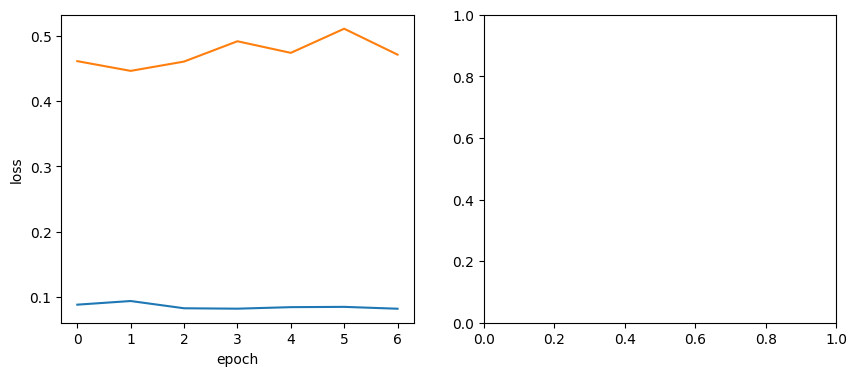

In [168]:
# 결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2 ,1)
plt.plot(range(len(train_loss_list)), train_loss_list, label='train loss')
plt.plot(range(len(valid_loss_list)), valid_loss_list, label='valid loss')
plt.ylabel('loss')
plt.xlabel('epoch')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), valid_acc_list, label='valid loss')

plt.legend()
plt.show()

In [169]:
# 최종 평가
######################
with torch.no_grad():
    test_loss = 0.0
    test_acc = 0.0
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device), y_test.to(device)
        pred_test = fmnist_model(X_test)
        test_loss += loss_fn(pred_test, y_test).item()
        test_acc += torch.sum(pred_test.argmax(dim=-1) ==y_test).item()
    test_loss /= len(test_loader)
    test_acc /= len(fmnist_testset)

In [ ]:
torch.save(fmnist_model, os.path.join(model_dir, model_name))
load_fmodel = torch.load('fashion-mnist_model.pt', weights_only=False)


### 위스콘신 유방암 데이터셋 - **이진분류(Binary Classification) 문제**

-   **이진 분류 문제 처리 모델의 두가지 방법**
    1. positive(1)일 확률을 출력하도록 구현
        - output layer: units=1, activation='sigmoid'
        - loss: binary_crossentropy
    2. negative(0)일 확률과 positive(1)일 확률을 출력하도록 구현 => 다중분류 처리 방식으로 해결
        - output layer: units=2, activation='softmax', y(정답)은 one hot encoding 처리
        - loss: categorical_crossentropy
-   위스콘신 대학교에서 제공한 종양의 악성/양성여부 분류를 위한 데이터셋
-   Feature
    -   종양에 대한 다양한 측정값들
-   Target의 class
    -   0 - malignant(악성종양)
    -   1 - benign(양성종양)


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

In [ ]:
# Dataset
X, y = load_breast_cancer(return_X_y=True)
y = y.reshape(-1, 1)
# X.shape, y.shape, X.dtype
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=0)

In [ ]:
# 전처리
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# class name <-> class index
classes = np.array(["악성종양", "양성종양"])
class_to_idx = {"악성종양":0, "양성종양":1}

In [ ]:
# Dataset
## 모델의 weight, bias -> float32. X, y는 weight, bias와 계산을 하게 되기 때문에 타입을 맞춰준다.
trainset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),  
    torch.tensor(y_train, dtype=torch.float32)
)
testset = TensorDataset(
    torch.tensor(X_test_scaled, dtype=torch.float32), 
    torch.tensor(y_test, dtype=torch.float32)
)

In [ ]:
trainset.classes = classes
trainset.class_to_idx = class_to_idx

In [ ]:
# DataLoader
train_loader = DataLoader(trainset, batch_size=200, shuffle=True, drop_last=True)
test_loader = DataLoader(testset, batch_size=100)

In [ ]:
######### 모델 정의
class BreastCancerModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.lr1 = nn.Linear(30, 32)
        self.lr2 = nn.Linear(32, 8)
        self.lr3 = nn.Linear(8, 1) # 출력 Layer 처리하는 함수. out_features=1 : positive일 확률.
        self.relu = nn.ReLU()
        self.logistic = nn.Sigmoid() # 입력값을 0 ~ 1 사이 실수로 반환. 

    def forward(self, X):
        X = self.lr1(X)
        X = self.relu(X)
        X = self.lr2(X)
        X = self.relu(X)
        # 출력 Layer
        output = self.lr3(X)
        output = self.logistic(output)
        return output

In [ ]:
b_model = BreastCancerModel()
b_model

In [ ]:
from torchinfo import summary
summary(b_model, (10, 30), device=device)

In [ ]:
# dummy data로 출력
dummy_x = torch.randn(10, 30)
# dummy_x.shape
result = b_model(dummy_x)
# result.shape
result

In [ ]:
(result > 0.5).type(torch.int32)  # bool -> int (True: 1, False: 0)

In [ ]:
lr = 0.001
epochs = 1000
######## 학습(train)
b_model = b_model.to(device)
optimizer = optim.Adam(b_model.parameters(), lr=lr)
loss_fn = nn.BCELoss()   # 함수이름: binary crossentropy

In [ ]:
import time

### 모델 학습(train) 로직 작성
#### 검증 결과 -> train loss, valid_loss, valid_accuracy
### 모델 성능이 개선될 때 마다 저장.
### 조기종료 - 10 epoch 동안 성능 개선이 없으면 조기종료

save_path = "saved_models/bc_model.pt"
best_score = torch.inf   # validation loss 기준으로 저장/조기종료 여부 확인.
patience = 10
trigger_cnt = 0

train_losses, valid_losses, valid_acces = [], [], []

s = time.time()
for epoch in range(epochs):
    ################### train #######################
    b_model.train()
    train_loss = 0.0
    for X_train, y_train in train_loader:
        X_train, y_train = X_train.to(device), y_train.to(device)
        pred = b_model(X_train)  # positive일 확률
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    ################### validation ##################
    b_model.eval()
    valid_loss = valid_acc = 0.0
    with torch.no_grad():
        for X_test, y_test in test_loader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            pred_test = b_model(X_test) # positive일 확률
            valid_loss += loss_fn(pred_test, y_test).item()
            #  이진 분류에서 accuracy
            valid_acc += torch.sum((pred_test > 0.5).type(torch.int32) == y_test).item()
        valid_loss /= len(test_loader)
        valid_acc /= len(test_loader.dataset)
        valid_losses.append(valid_loss)
        valid_acces.append(valid_acc)
    
    log_template = "[{:04d}/{}] train loss: {}, valid loss: {}, valid accuracy: {}"
    print(log_template.format(epoch+1, epochs, train_loss, valid_loss, valid_acc))
    # 모델 저장, 조기종료
    if valid_loss <  best_score: # 성능 개선
        print(f">>>>>> {epoch+1}에서 성능이 개선되어 저장합니다. {valid_loss}")
        torch.save(b_model, save_path)
        best_score = valid_loss
        trigger_cnt = 0
    else:
        trigger_cnt += 1
        if patience == trigger_cnt:
            print(f"{epoch+1} 에폭에서 조기종료 합니다. {best_score}에서 개선되지 않음.")
            break
    
e = time.time()
print("걸린시간(초):", e-s)

In [ ]:
## loss, acc 시각화

In [ ]:
best_model = torch.load(save_path)
best_model

In [ ]:
def predict_bc(model, X, device=device):
    # model로 X를 추론한 결과를 반환
    # label, 확률
    result = []
    with torch.no_grad():
        pred_proba = model(X)
        pred_class = (pred_proba > 0.5).type(torch.int32)
        for class_index, proba in zip(pred_class, pred_proba):
            # print(class_index, proba if class_index.item() == 1 else 1-proba)
            result.append((class_index.item(), proba if class_index.item() == 1 else 1-proba))
        return result

In [ ]:
new_data = torch.tensor(X_test_scaled[:5], dtype=torch.float32)
# print(new_data.shape)
result = predict_bc(best_model, new_data, device)

In [ ]:
result

# 모델 유형별 구현 정리

## 공통

-   Input layer(첫번째 Layer)의 in_features
    -   입력데이터의 feature(속성) 개수에 맞춰준다.
-   Hidden layer 수
    -   경험적(art)으로 정한다.
    -   Hidden layer에 Linear를 사용하는 경우 보통 feature 수를 줄여 나간다. (핵심 특성들을 추출해나가는 과정의 개념.)

## 회귀 모델

-   output layer의 출력 unit개수(out_features)
    -   정답의 개수
    -   ex
        -   집값: 1
        -   아파트가격, 단독가격, 빌라가격: 3 => y의 개수에 맞춘다.
-   출력 Layer에 적용하는 activation 함수
    -   일반적으로 **None**
    -   값의 범위가 설정되 있고 그 범위의 값을 출력하는 함수가 있을 경우
        -   ex) 0 ~ 1: logistic(Sigmoid), -1 ~ 1: hyperbolic tangent(Tanh)
-   loss함수
    -   MSELoss
-   평가지표
    -   MSE, RMSE, R square($R^2$)

## 다중분류 모델

-   output layer의 unit 개수
    -   정답 class(고유값)의 개수
-   출력 Layer에 적용하는 activation 함수
    -   Softmax: 클래스별 확률을 출력
-   loss함수
    -   **categrocial crossentropy**
    -   파이토치 함수
        -   **CrossEntropyLoss** = NLLLoss(정답) + LogSoftmax(모델 예측값)
        -   **NLLLoss**
            -   정답을 OneHot Encoding 처리 후 Loss를 계산한다.
            -   입력으로 LogSoftmax 처리한 모델 예측값과 onehot encoding 안 된 정답을 받는다.
        -   **LogSoftmax**
            -   입력값에 Softmax 계산후 그 Log를 계산한다.
                -   NLLLoss의 모델 예측값 입력값으로 처리할 때 사용한다.

```python
pred = model(input)
loss1 = nn.NLLLoss(nn.LogSoftmax(dim=-1)(pred), y)
# or
loss2 = nn.CrossEntropyLoss()(pred, y)
```

## 이진분류 모델

-   output layer의 unit 개수
    -   1개 (positive일 확률)
-   출력 Layer에 적용하는 activation 함수
    -   Sigmoid(Logistic)
-   loss 함수
    -   **Binary crossentropy**
    -   파이토치 함수: **BCELoss**
